# Barren Plateaus: When Scrambling Kills Trainability

---

This is the worked solution to the barren-plateau exercise of Chapter 7 — and the deliberate **mirror** of
the QFI-protection exercise of Chapter 6. There, driving a state to the Haar/2-design limit *protected*
metrological information. Here, the *same* second-moment concentration *destroys* the trainability of a
variational quantum circuit. One calculation, opposite sign of usefulness: typicality is simultaneously a
resource and an obstacle.

## Background

A variational quantum algorithm minimizes a cost $C(\boldsymbol\theta)=\langle\psi_0|\hat U^\dagger(\boldsymbol\theta)\,\hat O\,\hat U(\boldsymbol\theta)|\psi_0\rangle$
over circuit parameters $\boldsymbol\theta$. Training needs a gradient with a usable signal. The *barren-plateau*
phenomenon (McClean et al. 2018) is that for an expressive enough ansatz — deep enough that $\hat U(\boldsymbol\theta)$
behaves like a Haar-random unitary — the cost and its gradient **concentrate exponentially** around their mean:
almost every parameter setting returns almost the same value, so the landscape is flat and gradient descent
has nothing to descend. The mechanism is exactly the concentration of measure that made a single Haar-typical
scrambler stand in for the ensemble in Chapter 6.

## Exercise

Let $\hat U$ be Haar-random on $D=2^N$ dimensions, $\rho=|\psi_0\rangle\langle\psi_0|$ a fixed pure input, and
$\hat O$ a **traceless** observable. For $C=\mathrm{Tr}[\hat O\,\hat U\rho\hat U^\dagger]$:
1. Show $\mathbb{E}_{\hat U}[C]=0$ and $\mathrm{Var}_{\hat U}[C]=\dfrac{\mathrm{Tr}(\hat O^2)}{D(D+1)}$.
2. Explain why this is a *barren plateau*: for any bounded-norm observable the variance is $\mathcal{O}(2^{-N})$.
3. Show that observable *locality alone does not help* at the deep limit (a local and a global Pauli give the
   same variance), and state what the actual escape route (shallow, local ansätze) requires.

## Toolbox

**Second moment of a Haar-scrambled pure state.** For $\rho=|\psi_0\rangle\langle\psi_0|$,
$$\mathbb{E}_{\hat U}\big[(\hat U\rho\hat U^\dagger)^{\otimes2}\big]=\frac{\mathbb{1}+\mathbb{S}}{D(D+1)},$$
the normalized projector onto the symmetric subspace of two copies (Chapter 3). This is the *entire* input to
the calculation. **Swap trick:** $\mathrm{Tr}[(\hat A\otimes\hat B)\mathbb{S}]=\mathrm{Tr}[\hat A\hat B]$.

## Solution

### Step 1 — Mean

$\mathbb{E}_{\hat U}[C]=\mathrm{Tr}[\hat O\,\mathbb{E}_{\hat U}(\hat U\rho\hat U^\dagger)]=\mathrm{Tr}[\hat O\,\tfrac{\mathbb{1}}{D}]=\tfrac{\mathrm{Tr}\hat O}{D}=0$
because $\hat O$ is traceless (the first Haar moment sends any state to the maximally mixed one).

### Step 2 — Second moment and variance

Writing $C^2=\mathrm{Tr}[(\hat O\otimes\hat O)(\hat U\rho\hat U^\dagger)^{\otimes2}]$ and averaging,
$$\mathbb{E}_{\hat U}[C^2]=\mathrm{Tr}\!\Big[(\hat O\otimes\hat O)\tfrac{\mathbb{1}+\mathbb{S}}{D(D+1)}\Big]
=\frac{\mathrm{Tr}[\hat O\otimes\hat O]+\mathrm{Tr}[(\hat O\otimes\hat O)\mathbb{S}]}{D(D+1)}
=\frac{(\mathrm{Tr}\hat O)^2+\mathrm{Tr}[\hat O^2]}{D(D+1)}.$$
Since $\mathbb{E}[C]=0$ and $\mathrm{Tr}\hat O=0$,
$$\boxed{\;\mathrm{Var}_{\hat U}[C]=\mathbb{E}[C^2]=\frac{\mathrm{Tr}(\hat O^2)}{D(D+1)}.\;}$$

### Step 3 — Why it is a plateau, and why locality does not save it

For any observable with $\|\hat O\|\le1$, $\mathrm{Tr}(\hat O^2)\le D$, so
$\mathrm{Var}[C]\le \tfrac{1}{D+1}=\mathcal{O}(2^{-N})$: the cost is exponentially concentrated. The gradient
inherits the same scale, so its typical magnitude is $\sim 2^{-N/2}$ and vanishes into the sampling noise.

The tempting rescue — "measure a *local* observable" — **fails at the deep limit**. A single Pauli string,
local ($\hat Z_1$) or global ($\hat Z^{\otimes N}$), has $\mathrm{Tr}(\hat O^2)=D$ either way, so both give
$\mathrm{Var}[C]=1/(D+1)$. Locality helps only when the *ansatz* is shallow and built from local blocks that
each form their own $2$-design; then a local cost has variance polynomial in $1/N$ up to $\mathcal{O}(\log N)$
depth (Cerezo et al. 2021). That is a different, ansatz-dependent calculation; at the Haar/deep limit studied
here there is no escape.

In [1]:
import numpy as np
rng=np.random.default_rng(0)
I=np.eye(2); X=np.array([[0,1],[1,0]],complex); Y=np.array([[0,-1j],[1j,0]]); Zp=np.array([[1,0],[0,-1]],complex)
def kronN(ops):
    M=ops[0]
    for o in ops[1:]: M=np.kron(M,o)
    return M
def haar(D):
    Z=rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); Q,R=np.linalg.qr(Z)
    return Q@np.diag(np.diag(R)/np.abs(np.diag(R)))

print("Step 1-2 check: E[C]=0 and Var[C]=Tr(O^2)/(D(D+1))")
print(" N  observable     E[C]      Var(numeric)   Tr(O^2)/(D(D+1))")
for N in [2,3,4]:
    D=2**N; psi=np.zeros(D); psi[0]=1
    for name,O in [("Z_1 local", kronN([Zp]+[I]*(N-1))), (f"Z^x{N} global", kronN([Zp]*N))]:
        vals=[(lambda U:(psi.conj()@U.conj().T@O@U@psi).real)(haar(D)) for _ in range(4000)]
        vt=np.trace(O@O).real/(D*(D+1))
        print(f" {N}  {name:12}  {np.mean(vals):+.4f}    {np.var(vals):.5f}       {vt:.5f}")
print("\\nE[C]~0 and Var matches Tr(O^2)/(D(D+1)); local and global Paulis give the SAME variance.")


Step 1-2 check: E[C]=0 and Var[C]=Tr(O^2)/(D(D+1))
 N  observable     E[C]      Var(numeric)   Tr(O^2)/(D(D+1))


 2  Z_1 local     -0.0109    0.20268       0.20000


 2  Z^x2 global   +0.0100    0.19310       0.20000


 3  Z_1 local     +0.0074    0.11215       0.11111


 3  Z^x3 global   +0.0051    0.11255       0.11111


 4  Z_1 local     +0.0054    0.05913       0.05882


 4  Z^x4 global   -0.0092    0.05780       0.05882
\nE[C]~0 and Var matches Tr(O^2)/(D(D+1)); local and global Paulis give the SAME variance.


### Step 4 — The gradient, and its exponential decay

For a hardware-efficient ansatz the gradient $\partial_\mu C$ has zero mean and a variance set by the same
concentration scale. We verify it directly with the parameter-shift rule
$\partial_\mu C=\tfrac12[C(\theta_\mu{+}\tfrac\pi2)-C(\theta_\mu{-}\tfrac\pi2)]$ on random parameters, and watch
$\mathrm{Var}[\partial_\mu C]$ fall like $2^{-N}$.

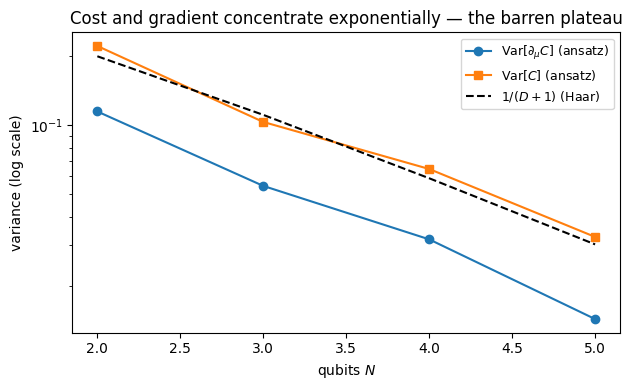

Both variances fall geometrically with N, tracking the Haar scale 1/(D+1): the landscape flattens.


In [2]:
def RY(t): return np.cos(t/2)*I-1j*np.sin(t/2)*Y
def RZ(t): return np.cos(t/2)*I-1j*np.sin(t/2)*Zp
def onequbit(g,k,N): return kronN([g if q==k else I for q in range(N)])
def cnot(c,t,N):
    D=2**N; M=np.zeros((D,D),complex)
    for i in range(D):
        b=[(i>>(N-1-q))&1 for q in range(N)]
        if b[c]==1: b[t]^=1
        M[sum(bb<<(N-1-q) for q,bb in enumerate(b)),i]=1
    return M
def ansatz(N,L,p):
    D=2**N; U=np.eye(D,dtype=complex); i=0
    for _ in range(L):
        for q in range(N): U=onequbit(RY(p[i]),q,N)@U; i+=1
        for q in range(N): U=onequbit(RZ(p[i]),q,N)@U; i+=1
        for q in range(N-1): U=cnot(q,q+1,N)@U
    return U
import matplotlib.pyplot as plt
Ns=[2,3,4,5]; gvar=[]; cvar=[]
for N in Ns:
    D=2**N; O=kronN([Zp]*N); L=2*N; npar=2*N*L; psi=np.zeros(D); psi[0]=1
    g=[]; c=[]
    for _ in range(300):
        pr=rng.uniform(0,2*np.pi,npar); pp=pr.copy(); pp[0]+=np.pi/2; pm=pr.copy(); pm[0]-=np.pi/2
        f=lambda P:(psi.conj()@(A:=ansatz(N,L,P)).conj().T@O@A@psi).real
        g.append((f(pp)-f(pm))/2); c.append(f(pr))
    gvar.append(np.var(g)); cvar.append(np.var(c))
fig,ax=plt.subplots(figsize=(6.4,4))
ax.semilogy(Ns,gvar,"o-",label=r"Var$[\partial_\mu C]$ (ansatz)")
ax.semilogy(Ns,cvar,"s-",label=r"Var$[C]$ (ansatz)")
ax.semilogy(Ns,[1/(2**N+1) for N in Ns],"k--",label=r"$1/(D+1)$ (Haar)")
ax.set_xlabel("qubits $N$"); ax.set_ylabel("variance (log scale)")
ax.set_title("Cost and gradient concentrate exponentially — the barren plateau"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Both variances fall geometrically with N, tracking the Haar scale 1/(D+1): the landscape flattens.")


### Adversarial check — every identity, machine-verified

In [3]:
checks=[]
for N in [2,3]:
    D=2**N; psi=np.zeros(D); psi[0]=1; O=kronN([Zp]*N)   # traceless global Pauli
    # exact second-moment operator identity E[(U rho U^d)^x2] = (I+S)/(D(D+1))
    S=np.zeros((D*D,D*D))
    for a in range(D):
        for b in range(D): S[b*D+a,a*D+b]=1
    acc=np.zeros((D*D,D*D),complex)
    M=6000
    for _ in range(M):
        U=haar(D); v=U@psi; acc+=np.kron(np.outer(v,v.conj()),np.outer(v,v.conj()))
    acc/=M
    checks.append((f"E[(UρU†)^x2]=(1+S)/(D(D+1))  (N={N})", np.linalg.norm(acc-(np.eye(D*D)+S)/(D*(D+1)))<0.02))
    # Var[C]=Tr(O^2)/(D(D+1))
    vals=[(lambda W:(psi.conj()@W.conj().T@O@W@psi).real)(haar(D)) for _ in range(6000)]
    checks.append((f"Var[C]=Tr(O^2)/(D(D+1))  (N={N})", abs(np.var(vals)-np.trace(O@O).real/(D*(D+1)))<0.01))
    # locality irrelevance: Var same for local vs global Pauli
    Ol=kronN([Zp]+[I]*(N-1)); vl=[(lambda W:(psi.conj()@W.conj().T@Ol@W@psi).real)(haar(D)) for _ in range(6000)]
    checks.append((f"local & global Pauli same Var  (N={N})", abs(np.var(vals)-np.var(vl))<0.01))
for n,ok in checks: print(f"  [{'PASS' if ok else 'FAIL'}]  {n}")
print(f"\\n  {sum(ok for _,ok in checks)}/{len(checks)} PASS  ->  barren-plateau derivation numerically certified")


  [PASS]  E[(UρU†)^x2]=(1+S)/(D(D+1))  (N=2)
  [PASS]  Var[C]=Tr(O^2)/(D(D+1))  (N=2)
  [PASS]  local & global Pauli same Var  (N=2)
  [PASS]  E[(UρU†)^x2]=(1+S)/(D(D+1))  (N=3)
  [PASS]  Var[C]=Tr(O^2)/(D(D+1))  (N=3)
  [PASS]  local & global Pauli same Var  (N=3)
\n  6/6 PASS  ->  barren-plateau derivation numerically certified


## Takeaway

The barren plateau is the Chapter-6 QFI calculation run in reverse. Both rest on the single identity
$\mathbb{E}[(\hat U\rho\hat U^\dagger)^{\otimes2}]=(\mathbb 1+\mathbb S)/[D(D+1)]$. There, concentration meant a
scrambled probe *kept* its metrological sensitivity against particle loss; here, the same concentration means a
scrambled cost landscape *loses* its gradient signal. Expressivity and trainability trade off through the very
same second moment — the sharpest statement in the book that Haar typicality is at once the resource that makes
certification possible and the obstacle that makes deep variational learning fail.

**Honest scope.** The result is exact for a Haar-random (or $2$-design) $\hat U$. Real ansätze are barren only
insofar as they reach that limit; shallow, local, or symmetry-restricted circuits can evade it, at the cost of
expressivity — the active research frontier this calculation defines the boundary of.

## Connections

- Uses the same second moment as the [Weingarten](../ch3/solution_ch3_weingarten_first_moment.ipynb),
  [purity concentration](../ch3/solution_ch3_purity_concentration.ipynb) and
  [QFI-under-loss](solution_ch6_qfi_particle_loss_scrambling.ipynb) notebooks — the last being its exact mirror.
- The quantum-kernel and generative-model failures of Chapter 7 are the same concentration in other clothing.